# Pyroomacoustics sine wave

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import librosa
from scipy.io import wavfile
import IPython.display as ipd

import pyroomacoustics as pra
import pyroadacoustics as pyroad
import dynamic_sound as ds

SMALL_SIZE = 18
MEDIUM_SIZE = 22
BIGGER_SIZE = 26

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
# Create anechoic room.
sample_rate = 48_000
room = pra.AnechoicRoom(fs=sample_rate, air_absorption=True, temperature=20.0, humidity=50.0)

# Place the microphone array around the origin.
mic_locs = np.c_[
    [0.0, 0.0, 1.0],
]
room.add_microphone_array(mic_locs)

# Add a source. We use a white noise signal for the source, and
# the source can be arbitrarily far because there are no walls.
amplitude = 1.0
frequency = 2_000
duration = 9.0
time = np.linspace(0, duration, int(sample_rate * duration))
x = amplitude * np.sin(2 * np.pi * frequency * time)
room.add_source([343.0, 0.0, 1.0], signal=x)

# run the simulation
room.simulate()

os.makedirs("_tmp", exist_ok=True)
room.mic_array.to_wav("_tmp/pra_sine_static.wav")

0.0021948337


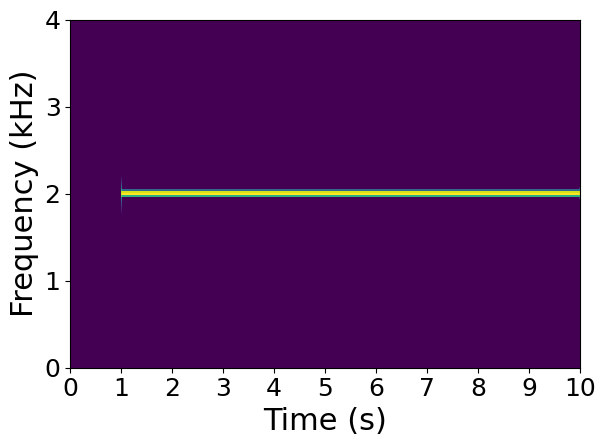

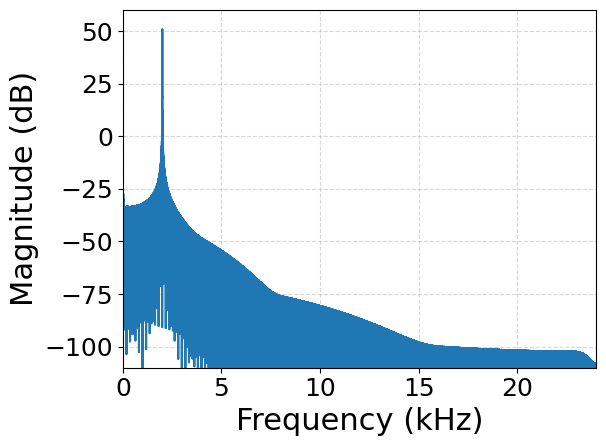

In [3]:

signal, sr = librosa.load("_tmp/pra_sine_static.wav", sr=None, mono=False)

if signal.ndim == 1:  # if single channel reshape to a common format (n_channels, n_samples)
    signal = signal.reshape(1, -1)

print(max(signal[0]))
ipd.display(ipd.Audio(signal[0], rate=sr))

D = librosa.stft(signal[0])
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure()
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='fft', cmap='viridis', vmin=-30, vmax=-0)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (kHz)")
plt.ylim(0, 4000)
plt.xlim(0, 10)
ax = plt.gca()
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'{y/1000:g}')
)
# plt.colorbar(format='%+2.0f dB')
# plt.title('Spectrogram')
plt.tight_layout()
plt.savefig("_tmp/sine_spectrogram_pyroom.png", dpi=300)
plt.show()

# --- FFT ---
X = np.fft.rfft(signal[0])
N = len(signal[0])
freq = np.fft.rfftfreq(N, d=1/sr)

# magnitude to dB
mag = np.abs(X)
mag_db = 20 * np.log10(mag)

plt.figure()
plt.plot(freq, mag_db, color='C0', )
plt.xlabel('Frequency (kHz)')
plt.ylabel('Magnitude (dB)')
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'{y/1000:g}')
)
#plt.title('Single-sided FFT of the signal (unnormalized amplitude)')
plt.xlim(0, sr / 2)
plt.ylim(-110, 60)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig("_tmp/sine_fft_pyroom.png", dpi=300)
plt.show()

# Pyroadacoustics sine wave

In [4]:
# Sampling Frequency
fs = 48_000

# Atmospheric Parameters
T = 20
p = 1
h_rel = 50

env = pyroad.Environment(fs = fs, temperature = T, pressure = p, rel_humidity = h_rel)

# Define source signal
t = np.arange(0,8,1/fs)
  
# Sin signal
amplitude = 1.0
frequency = 2_000
duration = 10.0
time = np.linspace(0, duration, int(fs * duration))
x = amplitude * np.sin(2 * np.pi * frequency * time)

env.add_source(position = np.array([343, 0, 1]), signal=x)

# Add microphone array
mic_array = np.array([[0,0,1], ])
env.add_microphone_array(mic_array)

interp_method = "Sinc"#  "Linear" "Allpass" "Sinc"
include_reflection = False
include_air_absorption = True

env.set_simulation_params(interp_method, include_reflection, include_air_absorption)

# Run simulation 
signal = env.simulate()

# Save Audio File
os.makedirs("_tmp", exist_ok=True)
interleaved = (np.clip(signal, -1.0, 1.0) * np.iinfo(np.int32).max).astype(np.int32).reshape(-1)
wavfile.write('_tmp/pyroad_sine_static.wav', fs, interleaved) # int32 (little-endian)

0.0012916354


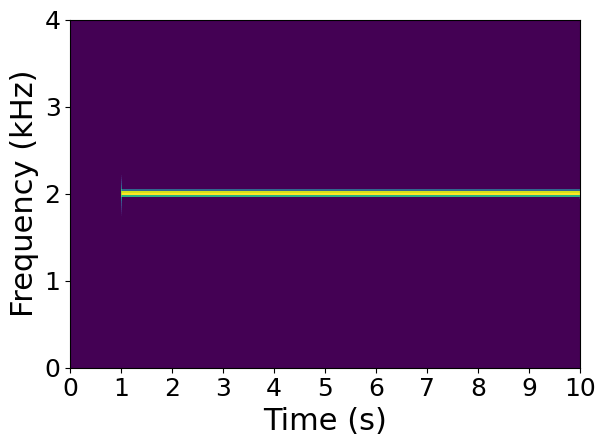

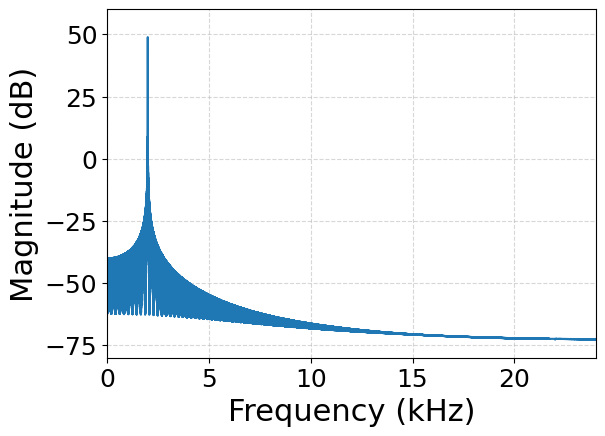

In [5]:

signal, sr = librosa.load("_tmp/pyroad_sine_static.wav", sr=None, mono=False)

if signal.ndim == 1:  # if single channel reshape to a common format (n_channels, n_samples)
    signal = signal.reshape(1, -1)

print(max(signal[0]))
ipd.display(ipd.Audio(signal[0], rate=sr))

D = librosa.stft(signal[0])
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure()
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='fft', cmap='viridis', vmin=-30, vmax=-0)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (kHz)")
plt.ylim(0, 4000)
plt.xlim(0, 10)
ax = plt.gca()
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'{y/1000:g}')
)
# plt.colorbar(format='%+2.0f dB')
# plt.title('Spectrogram')
plt.tight_layout()
plt.savefig("_tmp/sine_spectrogram_pyroad.png", dpi=300)
plt.show()

# --- FFT ---
X = np.fft.rfft(signal[0])
N = len(signal[0])
freq = np.fft.rfftfreq(N, d=1/sr)

# magnitude to dB
mag = np.abs(X)
mag_db = 20 * np.log10(mag + 1e-12)

plt.figure()
plt.plot(freq, mag_db, color='C0')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Magnitude (dB)')
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'{y/1000:g}')
)
#plt.title('Single-sided FFT of the signal (unnormalized amplitude)')
plt.xlim(0, sr / 2)
plt.ylim(-80, 60)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig("_tmp/sine_fft_pyroad.png", dpi=300)
plt.show()

# DynamicSound sine wave

In [6]:
source_path = ds.Path([
    [0.0,  343, 0, 1,   1, 0, 0, 0],
    [10.0,  343, 0, 1,   1, 0, 0, 0]
])
microphone_path = ds.Path([
    [0.0,  0, 0, 1,   1, 0, 0, 0],
    [10.0,  0, 0, 1,   1, 0, 0, 0]
])

# simulation environment
sim = ds.Simulation(
    temperature=20,
    pressure=1,
    relative_humidity=50
)

# microphone
mic_sample_rate = 48_000
microphone = ds.microphones.Microphone("_tmp/dynamicsound_sine_static.wav", sample_rate=mic_sample_rate)
sim.add_microphone(path=microphone_path, microphone=microphone)

# source
source = ds.sources.SineWave(frequency=2_000, amplitude=1.0)
sim.add_source(
    path=source_path,
    source=source
)

sim.run()

100%|██████████| 480000/480000 [32:24<00:00, 246.87it/s] 


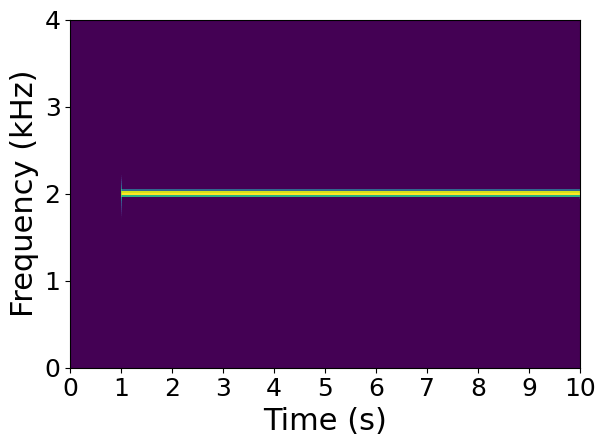

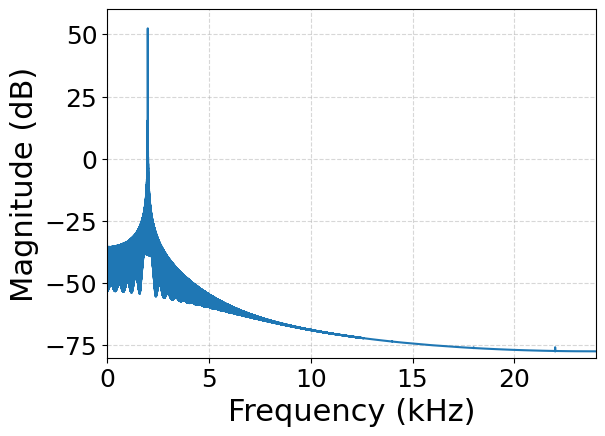

In [7]:

signal, sr = librosa.load("_tmp/dynamicsound_sine_static.wav", sr=None, mono=False)

if signal.ndim == 1:  # if single channel reshape to a common format (n_channels, n_samples)
    signal = signal.reshape(1, -1)
    
ipd.display(ipd.Audio(signal[0], rate=sr))

D = librosa.stft(signal[0])
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure()
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='fft', cmap='viridis', vmin=-30, vmax=-0)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (kHz)")
plt.ylim(0, 4000)
plt.xlim(0, 10)
ax = plt.gca()
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'{y/1000:g}')
)
# plt.colorbar(format='%+2.0f dB')
# plt.title('Spectrogram')
plt.tight_layout()
plt.savefig("_tmp/sine_spectrogram_dynamicsound.png", dpi=300)
plt.show()

# --- FFT ---
X = np.fft.rfft(signal[0])
N = len(signal[0])
freq = np.fft.rfftfreq(N, d=1/sr)

mag = np.abs(X)
mag_db = 20 * np.log10(mag + 1e-12)

plt.figure()
plt.plot(freq, mag_db, color='C0')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Magnitude (dB)')
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'{y/1000:g}')
)
#plt.title('Single-sided FFT of the signal (channel 0)')
plt.xlim(0, sr / 2)
plt.ylim(-80, 60)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig("_tmp/sine_fft_dynamicsound.png", dpi=300)
plt.show()
